In [1]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os
import ROOT
import glob


from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['text.usetex']=True
from plotters.make_paper_plots.event_displays import draw_event_display
from background_analysis.background_analysis_root import build_Zss_decay_tree, safe_get
from basic_functions import vars_fromyaml, check_inputpath, set_outputpath, chunk_list
from df_makers.data_to_pickle_function import remove_dot_etc


Welcome to JupyROOT 6.28/10


In [2]:
path = '/r02/lhcb/ejnw2/FCC_outputs_Jan26/outputs/MC_particles_full_prelim/root_bdtscores/bdtlh_nocut/p8_ee_Zbb_ecm91'#'/r02/lhcb/ejnw2/FCC_outputs_Jan26/outputs/prelims_incltauveto_evtdisp'

samples = {
            "Zbb": "combined_chunks_with_bdtcut0-99965.root",#"bb.root",#
          }

event_choice = { "Bd": 53,
                 "Zbb": 19,
                 "Zud": 43,
                 "Ksnunu":25,
               }

thrust_vars = [ "EVT_Thrust_x", "EVT_Thrust_y", "EVT_Thrust_z",
                "EVT_Thrust_xerr", "EVT_Thrust_yerr", "EVT_Thrust_zerr" ]

rec_vars = [ "Rec_n", "Rec_e", "Rec_m", "Rec_q", "Rec_p", "Rec_pt", "Rec_eta", "Rec_phi", "Rec_px", "Rec_py", "Rec_pz", "Rec_true_PDG", "Rec_indvtx" ]

vtx_vars = [ "Rec_vtx_n", "Rec_vtx_ntracks", "Rec_vtx_chi2", "Rec_vtx_isPV", "Rec_vtx_m", "Rec_vtx_x", "Rec_vtx_y", "Rec_vtx_z", "Rec_vtx_xerr", "Rec_vtx_yerr", "Rec_vtx_zerr" ] #, "Rec_vtx_indRP" ]


In [3]:
tr = uproot.open( f"{ os.path.join( path, samples['Zbb'] )}:events" )
evt_num = event_choice["Zbb"]
print(tr.arrays(["evt_id"], entry_start=evt_num, entry_stop=evt_num+1))


[{evt_id: 10310}]


[ 2.43270048e-03  1.17250765e-05 -1.83584332e-01]


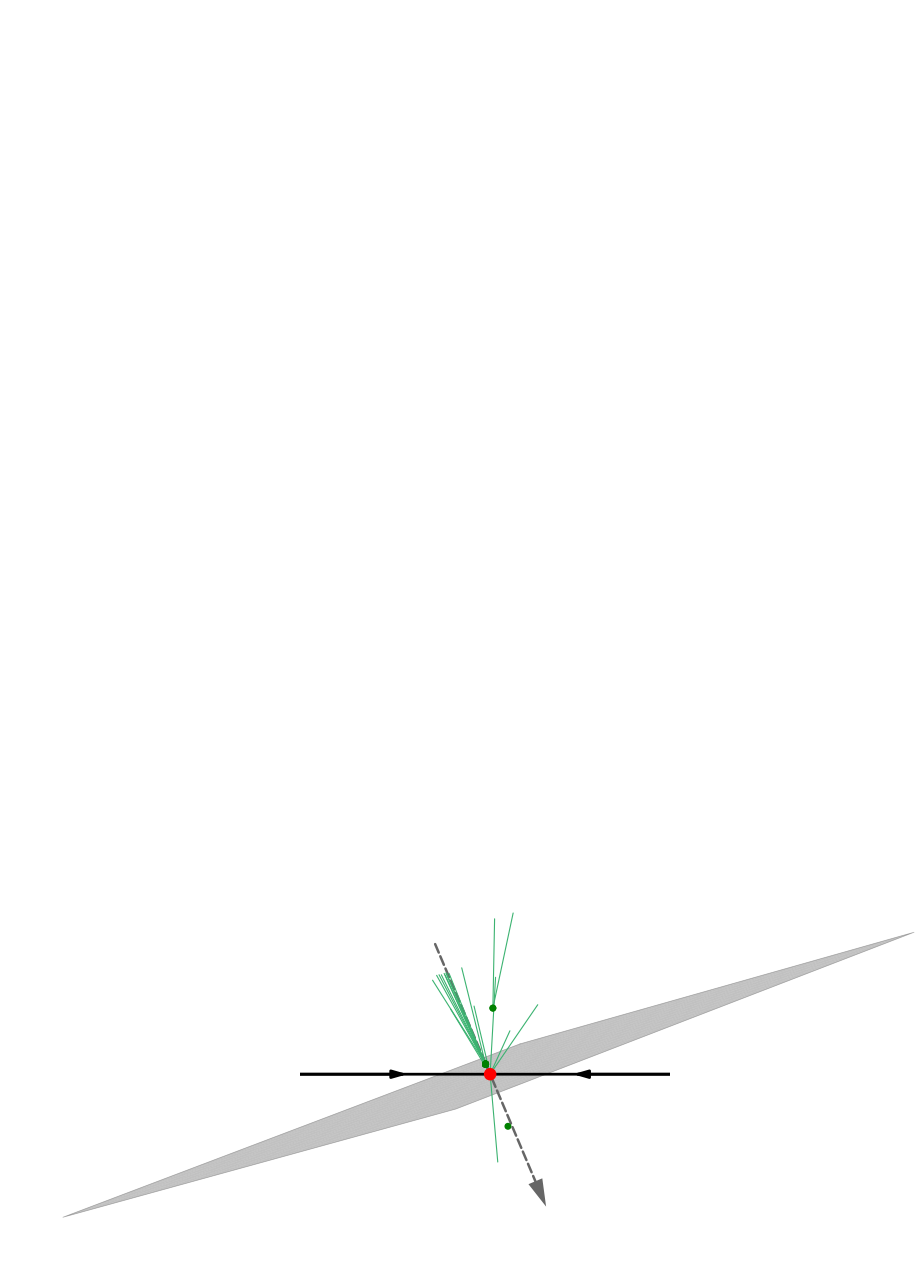

In [4]:
draw_event_display( os.path.join( path, samples["Zbb"] ), event_choice["Zbb"], elev=50, azim=90,  save=None)

In [14]:
# Proess  bkg
decay = "p8_ee_Zbb_ecm91"
inputpath = "/r02/lhcb/ejnw2/FCC_outputs_Jan26/outputs/MC_particles_full_prelim/root_bdtscores/bdtlh_nocut"
bdtcut=0.99965

#load combined files!
print(decay)
decay_inputpath = check_inputpath(os.path.join(inputpath,f'{decay}'))
filepath = glob.glob(os.path.join(decay_inputpath, f'combined_chunks_with_bdtcut{remove_dot_etc(str(bdtcut))}.root'))[0]

#print(filepath)
file = ROOT.TFile.Open(filepath)
tree = file.Get("events")   # events is TTree name

n_events = tree.GetEntries()
print(n_events)

for i, event in enumerate(tree):
    if i==event_choice["Zbb"]:
        info = build_Zss_decay_tree(event, decay, have_evt_ID=True)
        print(info)
    




p8_ee_Zbb_ecm91
83
{'evt_id': 10310, 'named_decay0': [['Bbar^*0'], [['Bbar0', 'gamma']], [['gamma', 'K0'], []], [[], ['K(S)0']], [['pi+', 'pi-']]], 'named_decay1': [['K^*(892)+'], [['K+', 'pi0']], [[], ['gamma', 'gamma']]], 'decay_chain_hemis_sgn0': [[1.0], [[1.0, 1.0]], [[1.0, 1.0], []], [[], [1.0]], [[1.0, 1.0]]], 'decay_chain_hemis_sgn1': [[1.0], [[1.0, 1.0]], [[], [1.0, 1.0]]], 'SS_b_parent': ['b', 'g'], 'SS_b_parent_hemis_sgn': [1, 1], 'SS_unstable_MC_particles_from_s': ['Bbar^*0', 'K^*(892)+'], 'SS_stable_MC_particles_from_s': [], 'OS_named_decay0': [['omega(782)0'], [['pi+', 'pi-', 'pi0']], [[], [], ['gamma', 'gamma']]], 'OS_named_decay1': [['rho(770)+'], [['pi+', 'pi0']], [[], ['gamma', 'gamma']]], 'OS_named_decay2': [['K0'], [['K(S)0']], [['pi+', 'pi-']]], 'OS_named_decay3': [['eta'], [['pi0', 'pi0', 'pi0']], [['gamma', 'gamma'], ['gamma', 'gamma'], ['gamma', 'gamma']]], 'OS_named_decay4': [['B_s^*0'], [['B_s()0', 'gamma']], [['D_s^*()-', 'pi+', "eta^'(958)0", 'rho(770)-', 'pi

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Repeating for $B \rightarrow K^{*0}\nu\bar{\nu}$ sample

In [2]:
Ksnun_path = "/r02/lhcb/ejnw2/FCC_outputs_additional_April26/outputs/ella_INVestigations/root_bdtscores/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu_combined_cut_0-99965.root"

[-8.33235495e-03 -4.26102706e-05  6.88252822e-02]


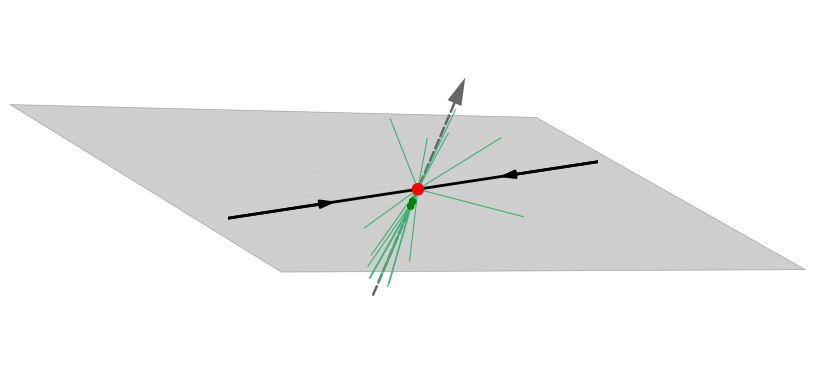

In [45]:
draw_event_display( Ksnun_path, event_choice["Ksnunu"], elev=60, azim=80,  save=None)

In [46]:
file = ROOT.TFile.Open(Ksnun_path)
tree = file.Get("events")   # events is TTree name

n_events = tree.GetEntries()
print(n_events)

decay="p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu"

target_index = event_choice["Ksnunu"]
tree.GetEntry(target_index)

info = build_Zss_decay_tree(tree, decay, have_evt_ID=True)
print(info)


29226
{'evt_id': 1476, 'named_decay0': [['Bbar^*0'], [['Bbar0', 'gamma']], [['K(S)0', 'nubar_e', 'nu_e'], []], [['pi+', 'pi-'], [], []]], 'named_decay1': [['pi0'], [['gamma', 'gamma']]], 'named_decay2': [['rho(770)0'], [['pi+', 'pi-']]], 'named_decay3': [['rho(770)0'], [['pi+', 'pi-']]], 'named_decay4': [['pi0'], [['gamma', 'gamma']]], 'named_decay5': [['rho(770)-'], [['pi-', 'pi0']], [[], ['gamma', 'gamma']]], 'decay_chain_hemis_sgn0': [[1.0], [[1.0, 1.0]], [[1.0, 1.0, 1.0], []], [[1.0, 1.0], [], []]], 'decay_chain_hemis_sgn1': [[1.0], [[1.0, 1.0]]], 'decay_chain_hemis_sgn2': [[1.0], [[1.0, 1.0]]], 'decay_chain_hemis_sgn3': [[1.0], [[1.0, 1.0]]], 'decay_chain_hemis_sgn4': [[1.0], [[1.0, 1.0]]], 'decay_chain_hemis_sgn5': [[1.0], [[-1.0, 1.0]], [[], [-1.0, 1.0]]], 'SS_b_parent': ['d', 'g'], 'SS_b_parent_hemis_sgn': [1, 1], 'SS_unstable_MC_particles_from_s': ['Bbar^*0', 'pi0', 'rho(770)0', 'rho(770)0', 'pi0', 'rho(770)-'], 'SS_stable_MC_particles_from_s': ['pi+', 'pi-'], 'OS_named_decay0

Error in <TFile::TFile>: file /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/ella_INVestigations/root_bdtscores/bdtlh_nocut/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0_bdt_friend.root does not exist
Error in <TFile::TFile>: file /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/ella_INVestigations/root_bdtscores/bdtlh_nocut/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0_bdt_friend.root does not exist
Error in <TFile::TFile>: file /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/ella_INVestigations/root_bdtscores/bdtlh_nocut/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0_bdt_friend.root does not exist
Error in <TFile::TFile>: file /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/ella_INVestigations/root_bdtscores/bdtlh_nocut/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0_bdt_friend.root does not exist
Error in <TFile::TFile>: file /r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/ella

## $K_s^0$ energy and therefore flight distance

In [5]:
def get_KS0_energy(event,KS_p_arr, KS_e_arr, KS_gamma ):
    recop = len(event.Rec_p)

    KS_m = 0.5#GeV

    pi_ID = []
    pi_rec_idx = []
    pi_px = []
    pi_py = []
    pi_pz = []
    pi_E = []


    for p in range(recop):


        ID = safe_get(event, "Rec_true_PDG", p)   
        M1_ID = safe_get(event, "Rec_true_M1", p)
        M2_ID = safe_get(event, "Rec_true_M2", p)

        if abs(M1_ID) ==310:
            pi_ID.append(ID)
            pi_rec_idx.append(p)
            pi_px.append(safe_get(event, "Rec_px", p))
            pi_py.append(safe_get(event, "Rec_py", p))
            pi_pz.append(safe_get(event, "Rec_pz", p))
            pi_E.append(safe_get(event, "Rec_e", p))

    # looking at cases where one KS
    if len(pi_ID) == 2:
        KS_px = sum(pi_px)
        KS_py = sum(pi_py)
        KS_pz = sum(pi_pz)
        KS_p = np.sqrt(KS_px**2 +KS_py**2+KS_pz**2)
        KS_e = sum(pi_E)


        KS_p_arr.append(KS_p)
        KS_e_arr.append(KS_e) 
        KS_gamma.append(KS_e/KS_m)


    if len(pi_ID) ==4:
        #assume first two beong to one KS - this is how indexing works so should be okay
        KS_px = pi_px[0]+pi_px[1]
        KS_py = pi_py[0]+pi_py[1]
        KS_pz = pi_pz[0]+pi_pz[1]
        KS_p = np.sqrt(KS_px**2 +KS_py**2+KS_pz**2)
        KS_E = pi_pz[0]+pi_pz[1]

In [6]:
## tuples without BDT applied
preseln_path = "/r02/lhcb/ejnw2/FCC_outputs_additional_April26/outputs/ella_INVestigations/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0.root"
file = ROOT.TFile.Open(preseln_path)
Ksnunu_presel_tree = file.Get("events")   # events is TTree name

KS_p_arr = []
KS_e_arr = []
KS_gamma = []


for i, event in enumerate(Ksnunu_presel_tree):
    get_KS0_energy(event,KS_p_arr, KS_e_arr, KS_gamma)





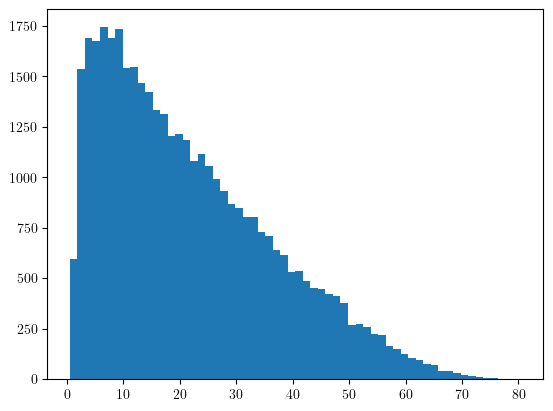

In [12]:
plt.hist(KS_gamma, bins =60)

plt.show()


In [13]:
gam = np.mean(KS_gamma)
print(f"mean gamma:{gam}")
tau_rest = 0.8954e-10

tau_lab = gam*tau_rest
print(f"lab lifetime:{tau_lab}")

print(f"lab FD:{tau_lab*3e8}")

mean gamma:21.694535187263792
lab lifetime:1.9425286806676e-09
lab FD:0.58275860420028


In [14]:
def get_KS0_decay_vtx(event, KS_decay_vtx_r, KS_decay_vtx_z):
    recop = len(event.Rec_p)

    KS_m = 0.5#GeV

    pi_ID = []
    pi_rec_idx = []
    pi_rec_orivtx_x = []
    pi_rec_orivtx_y = []
    pi_rec_orivtx_z = []



    for p in range(recop):


        ID = safe_get(event, "Rec_true_PDG", p)   
        M1_ID = safe_get(event, "Rec_true_M1", p)
        M2_ID = safe_get(event, "Rec_true_M2", p)

        if abs(M1_ID) ==310:
            pi_ID.append(ID)
            pi_rec_idx.append(p)
            pi_rec_orivtx_x.append(safe_get(event, "Rec_true_orivtx_x", p))
            pi_rec_orivtx_y.append(safe_get(event, "Rec_true_orivtx_y", p))
            pi_rec_orivtx_z.append(safe_get(event, "Rec_true_orivtx_z", p))


    # looking only at cases where one KS ie. from b2sunu - sufficient for now
    if len(pi_ID) == 2:
      KS_decay_vtx_r.append(np.sqrt(pi_rec_orivtx_x[0]**2 + pi_rec_orivtx_y[0]**2))
      KS_decay_vtx_z.append(pi_rec_orivtx_z[0])


KS_decay_vtx_r = []
KS_decay_vtx_z = []


for i, event in enumerate(Ksnunu_presel_tree):
    get_KS0_decay_vtx(event, KS_decay_vtx_r, KS_decay_vtx_z)

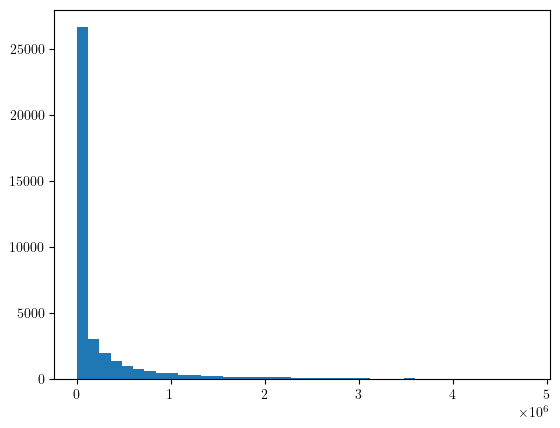

In [15]:
plt.hist(KS_decay_vtx_r, bins =40)

plt.show()

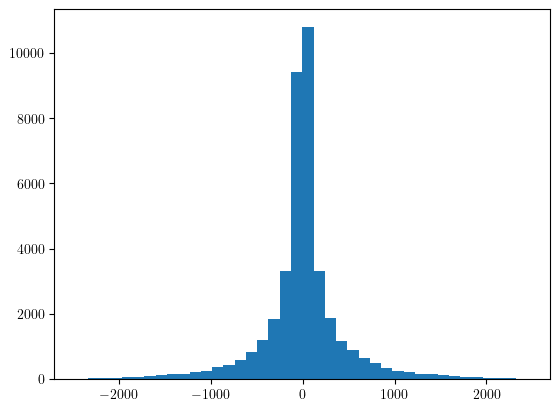

In [16]:
plt.hist(KS_decay_vtx_z, bins =40)

plt.show()

In [18]:
## Now repeat with stuff passing BDT
Ksnun_postBDT_path = "/r02/lhcb/ejnw2/FCC_outputs_additional_April26/outputs/ella_INVestigations/root_bdtscores/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu_combined_cut_0-99965.root"

file = ROOT.TFile.Open(Ksnun_postBDT_path)
Ksnunu_postBDT_tree = file.Get("events")   # events is TTree name


In [26]:
KS_decay_vtx_r_postBDT = []
KS_decay_vtx_z_postBDT  = []


for i, event in enumerate(Ksnunu_postBDT_tree):
    if i >= 5000:
        break
    get_KS0_decay_vtx(event, KS_decay_vtx_r_postBDT, KS_decay_vtx_z_postBDT)



IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



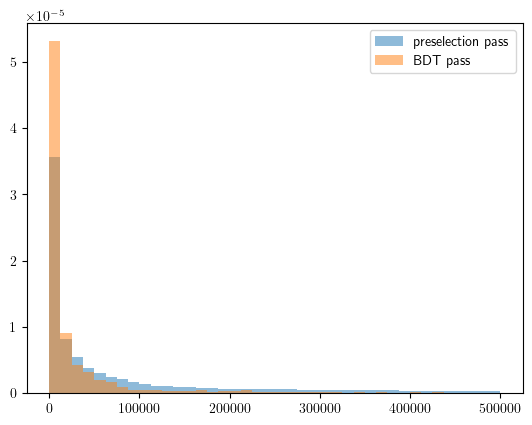

In [27]:

plt.hist(KS_decay_vtx_r, bins =40, density =True, range=(0,0.5e6), alpha =0.5, label="preselection pass")
plt.hist(KS_decay_vtx_r_postBDT, bins =40, density =True, range=(0,0.5e6), alpha =0.5, label="BDT pass")
plt.legend()
plt.show()

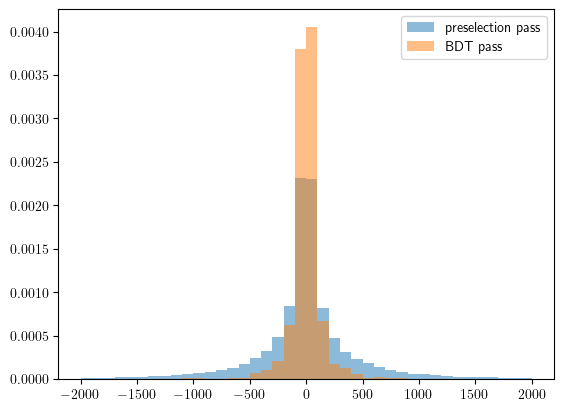

In [55]:
plt.hist(KS_decay_vtx_z, bins =40, density =True,range=(-2000,2000), alpha =0.5, label="preselection pass")
plt.hist(KS_decay_vtx_z_postBDT, bins =40, density =True,range=(-2000,2000), alpha =0.5, label="BDT pass")
plt.legend()
plt.show()

In [29]:
# Try looking at true Ks to see what we don't reco

def get_MC_KS_info(event, KS_dict):
    particles = len(event.MC_p)

    KS_m = 0.5#GeV


    for p in range(particles):

        ID = safe_get(event, "MC_PDG", p)   
        D1_idx = safe_get(event, "MC_D1", p)

        if abs(ID) ==310:
            KS_dict["KS_idx"].append(p)
            KS_dict["KS_p"].append(safe_get(event, "MC_p", p)  )
            KS_dict["KS_e"].append(safe_get(event, "MC_e", p) )
            KS_dict["KS_orivtx_x"].append(safe_get(event, "MC_orivtx_x", p) )
            KS_dict["KS_orivtx_y"].append(safe_get(event, "MC_orivtx_y", p) )
            KS_dict["KS_orivtx_z"].append(safe_get(event, "MC_orivtx_z", p) )
            KS_dict["KS_decvtx_x"].append(safe_get(event, "MC_orivtx_x", D1_idx) )
            KS_dict["KS_decvtx_y"].append(safe_get(event, "MC_orivtx_y", D1_idx) )
            KS_dict["KS_decvtx_z"].append(safe_get(event, "MC_orivtx_z", D1_idx) )




In [131]:
KS_dict_postBDT_quarterfull = {"KS_idx":[],
           "KS_p":[],
           "KS_e":[],
           "KS_orivtx_x":[],
           "KS_orivtx_y":[],
           "KS_orivtx_z":[],
           "KS_decvtx_x":[],
           "KS_decvtx_y":[],
           "KS_decvtx_z":[],}

nevents =  Ksnunu_postBDT_tree.GetEntries()
print(nevents)


for i, event in enumerate(Ksnunu_postBDT_tree):
    if i >= nevents/4:
        break
    get_MC_KS_info(event, KS_dict_postBDT_quarterfull)

29226


KeyboardInterrupt: 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [128]:
preseln_path = "/r02/lhcb/ejnw2/FCC_outputs_additional_April26/outputs/ella_INVestigations/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0.root"
preseln_file = ROOT.TFile.Open(preseln_path)
Ksnunu_presel_tree = preseln_file.Get("events")

KS_dict_presel = {"KS_idx":[],
           "KS_p":[],
           "KS_e":[],
           "KS_orivtx_x":[],
           "KS_orivtx_y":[],
           "KS_orivtx_z":[],
           "KS_decvtx_x":[],
           "KS_decvtx_y":[],
           "KS_decvtx_z":[],}

nevents =  Ksnunu_presel_tree.GetEntries()
print(nevents)


for i, event in enumerate(Ksnunu_presel_tree):
    get_MC_KS_info(event, KS_dict_presel)

80828


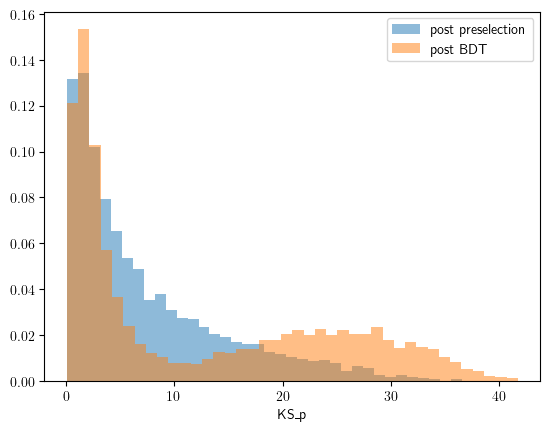

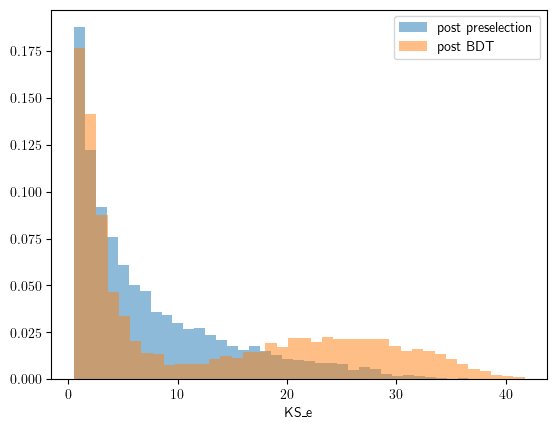

In [34]:
for var in ["KS_p","KS_e"]:
    plt.hist(KS_dict_presel[var], bins =40, density =True,  alpha =0.5, label="post preselection")
    plt.hist(KS_dict_postBDT_quarterfull[var], bins =40, density =True,  alpha =0.5, label="post BDT")
    plt.xlabel(var)
    plt.legend()
    plt.show()
    

In [ ]:

plt.hist(KS_dict_presel["KS_p"], bins =40, density =False, range=(10,45),  alpha =0.5, label="Post preselection")
plt.hist(KS_dict_postBDT_quarterfull["KS_p"], bins =40, density =False, range=(10,45), alpha =0.5, label="Post BDT")
plt.xlabel("KS_p")
plt.legend()
plt.show()

In [35]:
def get_KS_FD(KS_dict):
    FD_x = np.array(KS_dict["KS_decvtx_x"]) - np.array(KS_dict["KS_orivtx_x"])
    FD_y = np.array(KS_dict["KS_decvtx_y"]) - np.array(KS_dict["KS_orivtx_y"])
    FD_z = np.array(KS_dict["KS_decvtx_z"]) - np.array(KS_dict["KS_orivtx_z"])

    FD = np.sqrt(FD_x**2 + FD_y**2 + FD_z**2)

    return FD

def get_KS_decvtx_r(KS_dict):
    decvtx_r = np.sqrt(np.array(KS_dict["KS_decvtx_x"])**2+ np.array(KS_dict["KS_decvtx_y"])**2)
    return decvtx_r



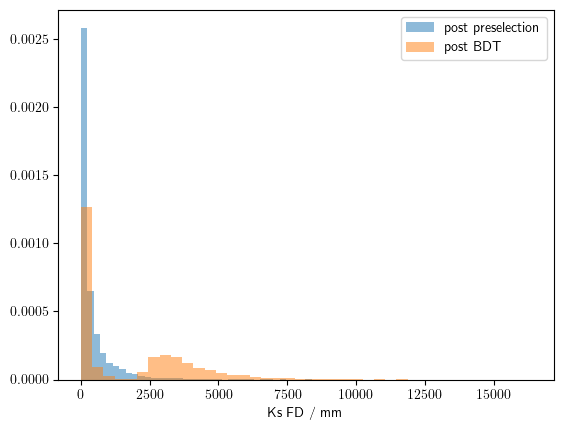

In [36]:
plt.hist(get_KS_FD(KS_dict_presel), bins =40, density =True,  alpha =0.5, label="post preselection")
plt.hist(get_KS_FD(KS_dict_postBDT_quarterfull), bins =40, density =True,  alpha =0.5, label="post BDT")
plt.xlabel("Ks FD / mm")
plt.legend()
plt.show()

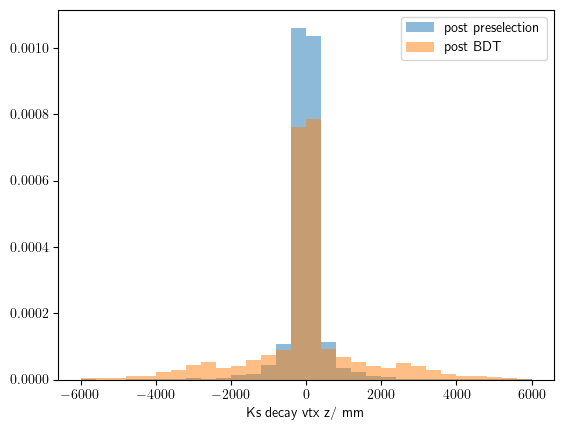

In [48]:
plt.hist(KS_dict_presel["KS_decvtx_z"], bins =30, density =True,  range = (-6000,6000), alpha =0.5, label="post preselection")
plt.hist(KS_dict_postBDT_quarterfull["KS_decvtx_z"], bins =30, density =True, range = (-6000,6000), alpha =0.5, label="post BDT")
plt.xlabel("Ks decay vtx z/ mm")
plt.legend()
plt.show()

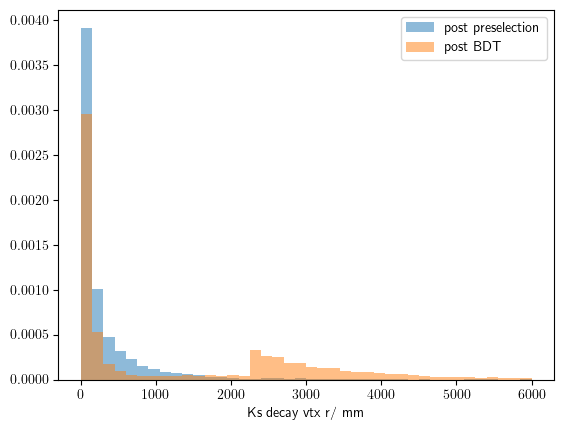

In [47]:
plt.hist(get_KS_decvtx_r(KS_dict_presel), bins =40, density =True, range = (0,6000),  alpha =0.5, label="post preselection")
plt.hist(get_KS_decvtx_r(KS_dict_postBDT_quarterfull), bins =40, density =True, range = (0,6000),  alpha =0.5, label="post BDT")
plt.xlabel("Ks decay vtx r/ mm")
plt.legend()
plt.show()

In [54]:
#fraction of events with r>2100 (ie decaying outside tracker) # noting this is ALL KS - some completely okay reco

print(sum([get_KS_decvtx_r(KS_dict_postBDT_quarterfull)[i] >= 2100 for i in range(len(get_KS_decvtx_r(KS_dict_postBDT)))]))
print(sum([get_KS_decvtx_r(KS_dict_postBDT_quarterfull)[i]<2100 for i in range(len(get_KS_decvtx_r(KS_dict_postBDT)))]))


2974
4941


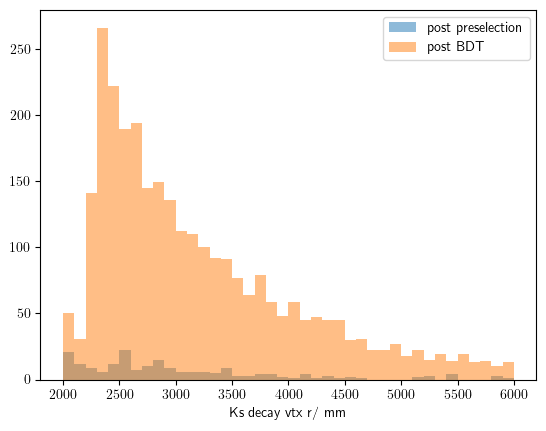

In [43]:
plt.hist(get_KS_decvtx_r(KS_dict_presel), bins =40, range = (2000,6000),density =False,  alpha =0.5, label="post preselection")
plt.hist(get_KS_decvtx_r(KS_dict_postBDT_quarterfull), bins =40, range = (2000,6000), density =False,  alpha =0.5, label="post BDT")
plt.xlabel("Ks decay vtx r/ mm")
plt.legend()
plt.show()

From comparison of MC Ks with the reconstructed ones, it looks like the ones whcih we don't reconstruct are the very high E/p ones where the FD ends up being very large and the KS decay vertex sits around 2-4m from the IP in the radial direction.

## Trying to look at SS Ks only

In [56]:
def calc_cos_theta(px,py,pz,utx,uty,utz):
    cosTheta = (px*utx+py*uty+pz*utz)/np.sqrt(px**2+py**2+pz**2)
    return cosTheta

In [112]:
#Function to reconstuct Ks if only 2,3 or 4 pions with KS true mother ID
'''def get_SS_reco_KS0_decay_vtx(event, KS_decay_vtx_r, KS_decay_vtx_z,KS_px_arr,KS_py_arr,KS_pz_arr):
    recop = len(event.Rec_p)

    KS_m = 0.5#GeV

    pi_ID = []
    pi_rec_idx = []
    pi_rec_orivtx_x = []
    pi_rec_orivtx_y = []
    pi_rec_orivtx_z = []

    pi_rec_px = []
    pi_rec_py = []
    pi_rec_pz = []


    for p in range(recop):

        ID = safe_get(event, "Rec_true_PDG", p)   
        M1_ID = safe_get(event, "Rec_true_M1", p)
        M2_ID = safe_get(event, "Rec_true_M2", p)
        pi_SS_flag = safe_get(event,"Rec_in_hemisEmin",p)

        if abs(M1_ID) ==310:
            pi_ID.append(ID)
            pi_rec_idx.append(p)
            pi_rec_orivtx_x.append(safe_get(event, "Rec_true_orivtx_x", p))
            pi_rec_orivtx_y.append(safe_get(event, "Rec_true_orivtx_y", p))
            pi_rec_orivtx_z.append(safe_get(event, "Rec_true_orivtx_z", p))

            pi_rec_px.append(safe_get(event, "Rec_px", p))
            pi_rec_py.append(safe_get(event, "Rec_py", p))
            pi_rec_pz.append(safe_get(event, "Rec_pz", p))

            Tx = safe_get(event, "EVT_unitThrust_x", p)
            Ty = safe_get(event, "EVT_unitThrust_y", p)
            Tz = safe_get(event, "EVT_unitThrust_z", p)


    # looking only at cases where one KS ie. from b2sunu - sufficient for now
    if len(pi_ID) == 2:
      KS_px = sum(pi_rec_px)
      KS_py = sum(pi_rec_py)
      KS_pz = sum(pi_rec_pz)


      cosTheta = calc_cos_theta(KS_px,KS_py,KS_pz,Tx,Ty,Tz)

      
      if cosTheta>0:
      
        KS_decay_vtx_r.append(np.sqrt(pi_rec_orivtx_x[0]**2 + pi_rec_orivtx_y[0]**2))
        KS_decay_vtx_z.append(pi_rec_orivtx_z[0])

        KS_px_arr.append(KS_px)
        KS_py_arr.append(KS_py)
        KS_pz_arr.append(KS_pz)

    if len(pi_ID) == 3: 
        first_pi_orvtx = pi_rec_orivtx_x[0]
        first_pi_pair = [i for i, x in enumerate(pi_rec_orivtx_x) if x == first_pi_orvtx]

        if len(first_pi_pair)==2:
            first_KS_px = pi_rec_px[first_pi_pair[0]]+ pi_rec_px[first_pi_pair[1]]
            first_KS_py = pi_rec_py[first_pi_pair[0]]+ pi_rec_py[first_pi_pair[1]]
            first_KS_pz = pi_rec_pz[first_pi_pair[0]]+ pi_rec_pz[first_pi_pair[1]]

            first_KS_cosTheta = calc_cos_theta(first_KS_px,first_KS_py,first_KS_pz,Tx,Ty,Tz)

            if first_KS_cosTheta>0:
                KS_decay_vtx_r.append(np.sqrt(pi_rec_orivtx_x[0]**2 + pi_rec_orivtx_y[0]**2))
                KS_decay_vtx_z.append(pi_rec_orivtx_z[0])

                KS_px_arr.append(first_KS_px)
                KS_py_arr.append(first_KS_py)
                KS_pz_arr.append(first_KS_pz)
        else:
            second_pi_pair = [i for i, x in enumerate(pi_rec_orivtx_x) if x != first_pi_orvtx]
            if len(second_pi_pair)==2:
                second_KS_px = pi_rec_px[second_pi_pair[0]]+ pi_rec_px[second_pi_pair[1]]
                second_KS_py = pi_rec_py[second_pi_pair[0]]+ pi_rec_py[second_pi_pair[1]]
                second_KS_pz = pi_rec_pz[second_pi_pair[0]]+ pi_rec_pz[second_pi_pair[1]]

                second_KS_cosTheta = calc_cos_theta(second_KS_px,second_KS_py,second_KS_pz,Tx,Ty,Tz)

                
                if second_KS_cosTheta>0:
                    KS_decay_vtx_r.append(np.sqrt(pi_rec_orivtx_x[second_pi_pair[0]]**2 + pi_rec_orivtx_y[second_pi_pair[0]]**2))
                    KS_decay_vtx_z.append(pi_rec_orivtx_z[second_pi_pair[0]])

                    KS_px_arr.append(second_KS_px)
                    KS_py_arr.append(second_KS_py)
                    KS_pz_arr.append(second_KS_pz)





    if len(pi_ID) == 4: # ie. if two Ks, assume first two pions from one Ks
        
        first_pi_orvtx = pi_rec_orivtx_x[0]
        first_pi_pair = [i for i, x in enumerate(pi_rec_orivtx_x) if x == first_pi_orvtx]

        first_KS_px = pi_rec_px[first_pi_pair[0]]+ pi_rec_px[first_pi_pair[1]]
        first_KS_py = pi_rec_py[first_pi_pair[0]]+ pi_rec_py[first_pi_pair[1]]
        first_KS_pz = pi_rec_pz[first_pi_pair[0]]+ pi_rec_pz[first_pi_pair[1]]

        first_KS_cosTheta = calc_cos_theta(first_KS_px,first_KS_py,first_KS_pz,Tx,Ty,Tz)

        if first_KS_cosTheta>0:
            KS_decay_vtx_r.append(np.sqrt(pi_rec_orivtx_x[0]**2 + pi_rec_orivtx_y[0]**2))
            KS_decay_vtx_z.append(pi_rec_orivtx_z[0])

            KS_px_arr.append(first_KS_px)
            KS_py_arr.append(first_KS_py)
            KS_pz_arr.append(first_KS_pz)
        
        
        second_pi_pair = [i for i, x in enumerate(pi_rec_orivtx_x) if x != first_pi_orvtx]

        second_KS_px = pi_rec_px[second_pi_pair[0]]+ pi_rec_px[second_pi_pair[1]]
        second_KS_py = pi_rec_py[second_pi_pair[0]]+ pi_rec_py[second_pi_pair[1]]
        second_KS_pz = pi_rec_pz[second_pi_pair[0]]+ pi_rec_pz[second_pi_pair[1]]

        second_KS_cosTheta = calc_cos_theta(second_KS_px,second_KS_py,second_KS_pz,Tx,Ty,Tz)

        
        if second_KS_cosTheta>0:
            KS_decay_vtx_r.append(np.sqrt(pi_rec_orivtx_x[second_pi_pair[0]]**2 + pi_rec_orivtx_y[second_pi_pair[0]]**2))
            KS_decay_vtx_z.append(pi_rec_orivtx_z[second_pi_pair[0]])

            KS_px_arr.append(second_KS_px)
            KS_py_arr.append(second_KS_py)
            KS_pz_arr.append(second_KS_pz)'''


#replacing with function which works for an arbitraty number of pi with Ks parent (only looking at charged)
def get_SS_reco_KS0_decay_vtx(event, KS_decay_vtx_r, KS_decay_vtx_z, KS_px_arr, KS_py_arr, KS_pz_arr):
    recop = len(event.Rec_p)

    # Standard dictionary to group pions
    ks_candidates = {}

    Tx, Ty, Tz = None, None, None

    for p in range(recop):
        M1_ID = safe_get(event, "Rec_true_M1", p)

        if abs(M1_ID) == 310:
            vx = safe_get(event, "Rec_true_orivtx_x", p)
            vy = safe_get(event, "Rec_true_orivtx_y", p)
            vz = safe_get(event, "Rec_true_orivtx_z", p)

            px = safe_get(event, "Rec_px", p)
            py = safe_get(event, "Rec_py", p)
            pz = safe_get(event, "Rec_pz", p)

            vtx_key = (round(vx, 5), round(vy, 5), round(vz, 5))


            # setdefault checks if vtx_key exists. If not, it creates it with an empty list [].
            # Then it appends the momentum
            ks_candidates.setdefault(vtx_key, []).append((px, py, pz))

            if Tx is None:
                Tx = safe_get(event, "EVT_unitThrust_x", p)
                Ty = safe_get(event, "EVT_unitThrust_y", p)
                Tz = safe_get(event, "EVT_unitThrust_z", p)

    if not ks_candidates:
        return


    for (vx, vy, vz), pions in ks_candidates.items():
        if len(pions) >= 2:
            KS_px = sum(pi[0] for pi in pions)
            KS_py = sum(pi[1] for pi in pions)
            KS_pz = sum(pi[2] for pi in pions)

            cosTheta = calc_cos_theta(KS_px, KS_py, KS_pz, Tx, Ty, Tz)

            if cosTheta > 0:
                KS_decay_vtx_r.append(np.sqrt(vx**2 + vy**2))
                KS_decay_vtx_z.append(vz)

                KS_px_arr.append(KS_px)
                KS_py_arr.append(KS_py)
                KS_pz_arr.append(KS_pz)






# Looking at true SS Ks

def get_SS_MC_KS_info(event, KS_dict):
    particles = len(event.MC_p)

    KS_m = 0.5#GeV


    for p in range(particles):

        ID = safe_get(event, "MC_PDG", p)   
        D1_idx = safe_get(event, "MC_D1", p)
        D1_id = safe_get(event, "MC_PDG", D1_idx)

        if abs(ID) ==310 and abs(D1_id) == 211: #ie. only look at charge pion daughters
            KS_px = safe_get(event, "MC_px", p)
            KS_py = safe_get(event, "MC_py", p)
            KS_pz = safe_get(event, "MC_pz", p)

            Tx = safe_get(event, "EVT_unitThrust_x", p)
            Ty = safe_get(event, "EVT_unitThrust_y", p)
            Tz = safe_get(event, "EVT_unitThrust_z", p)

            cosTheta = calc_cos_theta(KS_px,KS_py,KS_pz,Tx,Ty,Tz)

            if cosTheta >0:

                KS_dict["KS_idx"].append(p)
                KS_dict["KS_p"].append(safe_get(event, "MC_p", p)  )
                KS_dict["KS_px"].append(safe_get(event, "MC_px", p)  )
                KS_dict["KS_py"].append(safe_get(event, "MC_py", p)  )
                KS_dict["KS_pz"].append(safe_get(event, "MC_pz", p)  )
                KS_dict["KS_e"].append(safe_get(event, "MC_e", p) )
                KS_dict["KS_orivtx_x"].append(safe_get(event, "MC_orivtx_x", p) )
                KS_dict["KS_orivtx_y"].append(safe_get(event, "MC_orivtx_y", p) )
                KS_dict["KS_orivtx_z"].append(safe_get(event, "MC_orivtx_z", p) )
                KS_dict["KS_decvtx_x"].append(safe_get(event, "MC_orivtx_x", D1_idx) )
                KS_dict["KS_decvtx_y"].append(safe_get(event, "MC_orivtx_y", D1_idx) )
                KS_dict["KS_decvtx_z"].append(safe_get(event, "MC_orivtx_z", D1_idx) )


In [113]:
KS_decay_vtx_r = []
KS_decay_vtx_z = []
KS_px_arr = []
KS_py_arr = []
KS_pz_arr = []

KS_dict_postBDT = {"KS_idx":[],
           "KS_p":[],
           "KS_px":[],
           "KS_py":[],
           "KS_pz":[],
           "KS_e":[],
           "KS_orivtx_x":[],
           "KS_orivtx_y":[],
           "KS_orivtx_z":[],
           "KS_decvtx_x":[],
           "KS_decvtx_y":[],
           "KS_decvtx_z":[],}


for i, event in enumerate(Ksnunu_postBDT_tree):
    if i >= 2000:
        break
    get_SS_reco_KS0_decay_vtx(event, KS_decay_vtx_r, KS_decay_vtx_z, KS_px_arr,KS_py_arr,KS_pz_arr)
    get_SS_MC_KS_info(event, KS_dict_postBDT)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



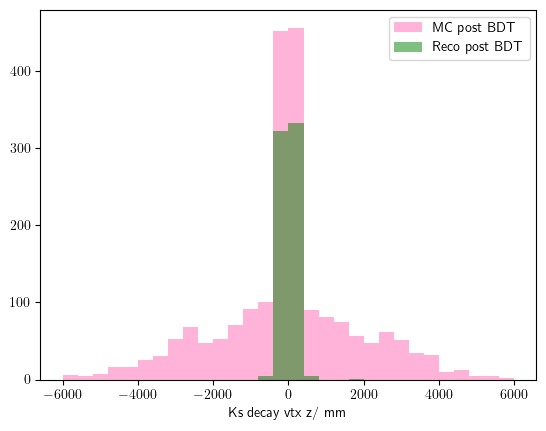

In [123]:

plt.hist(KS_dict_postBDT["KS_decvtx_z"], bins =30, density =False, range = (-6000,6000), alpha =0.5, label="MC post BDT",color="hotpink")
plt.hist(KS_decay_vtx_z, bins =30, density =False,  range = (-6000,6000), alpha =0.5, label="Reco post BDT", color="green")
plt.xlabel("Ks decay vtx z/ mm")
plt.legend()
plt.show()

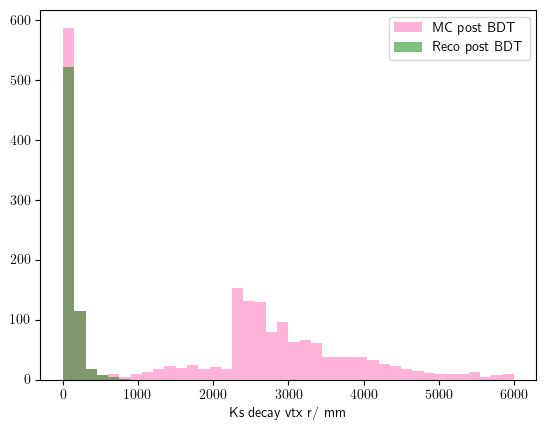

In [122]:


plt.hist(get_KS_decvtx_r(KS_dict_postBDT), bins =40, density =False, range = (0,6000), alpha =0.5, label="MC post BDT", color="hotpink")
plt.hist(KS_decay_vtx_r, bins =40, density =False,  range = (0,6000), alpha =0.5, label="Reco post BDT", color="green")
plt.xlabel("Ks decay vtx r/ mm")
plt.legend()
plt.show()

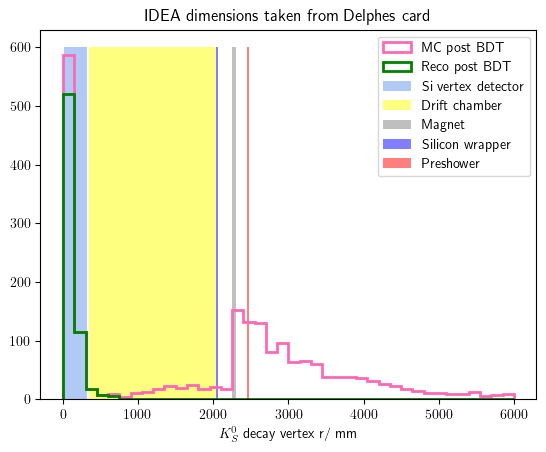

In [116]:
import matplotlib.patches as patches

plt.title("IDEA dimensions taken from Delphes card")

plt.hist(get_KS_decvtx_r(KS_dict_postBDT), bins =40, density =False, range = (0,6000), histtype='step',linewidth=2, label="MC post BDT", color="hotpink")
plt.hist(KS_decay_vtx_r, bins =40, density =False,  range = (0,6000), histtype='step',linewidth=2, label="Reco post BDT", color="green")
mag = patches.Rectangle(
    xy=(2250, 0),     # Bottom-left corner
    width=50,           
    height=600,         
    facecolor='gray',  
    alpha=0.5,          
    edgecolor=None,  
    label="Magnet" 
)
Si_vtx = patches.Rectangle(
    xy=(12, 0),     
    width=303,           
    height=600,         
    facecolor='cornflowerblue',   
    alpha=0.5,          
    edgecolor=None,  
    label="Si vertex detector" 
)
drift_chmb = patches.Rectangle(
    xy=(345, 0),     
    width=1695,           
    height=600,         
    facecolor='yellow',   
    alpha=0.5,         
    edgecolor=None, 
    label="Drift chamber" 
)
Si_wrapper = patches.Rectangle(
    xy=(2040, 0),     
    width=20,          
    height=600,        
    facecolor='blue',  
    alpha=0.5,         
    edgecolor=None,  
    label="Silicon wrapper" 
)

preshower = patches.Rectangle(
    xy=(2450, 0),     
    width=20,          
    height=600,        
    facecolor='red',  
    alpha=0.5,         
    edgecolor=None,  
    label="Preshower" 
)

plt.gca().add_patch(Si_vtx)
plt.gca().add_patch(drift_chmb)
plt.gca().add_patch(mag)
plt.gca().add_patch(Si_wrapper)
plt.gca().add_patch(preshower)
plt.xlabel("$K_S^0$ decay vertex r/ mm")
plt.legend()
plt.show()

In [117]:
print(len(get_KS_decvtx_r(KS_dict_postBDT)))
print(len(KS_decay_vtx_r))

2074
665


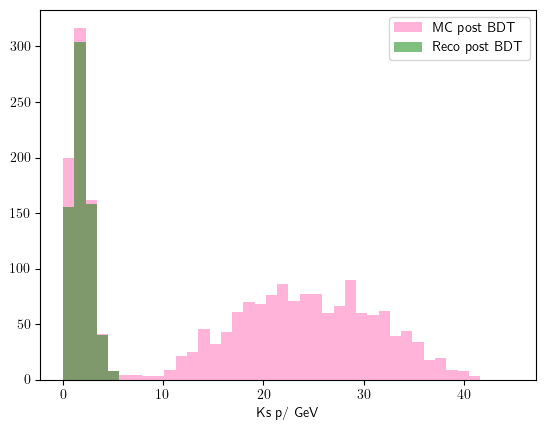

In [125]:


plt.hist(KS_dict_postBDT["KS_p"], bins =40, density =False, range = (0,45), alpha =0.5, label="MC post BDT", color="hotpink")
plt.hist(np.sqrt(np.array(KS_px_arr)**2+np.array(KS_py_arr)**2+np.array(KS_pz_arr)**2), bins =40, density =False,  range = (0,45), alpha =0.5, label="Reco post BDT", color="green")
plt.xlabel("Ks p/ GeV")
plt.legend()
plt.show()

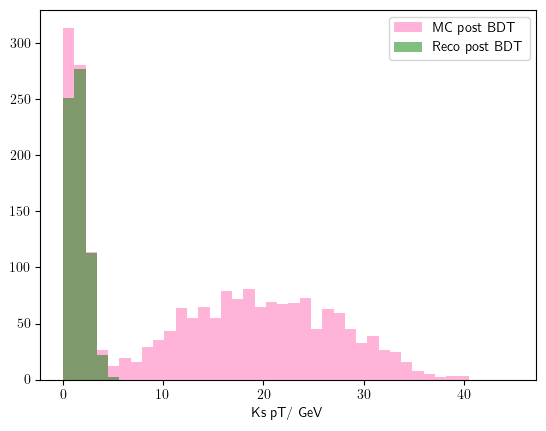

In [126]:


plt.hist(np.sqrt(np.array(KS_dict_postBDT["KS_px"])**2+np.array(KS_dict_postBDT["KS_py"])**2), bins =40, density =False, range = (0,45), alpha =0.5, label="MC post BDT", color="hotpink")
plt.hist(np.sqrt(np.array(KS_px_arr)**2+np.array(KS_py_arr)**2), bins =40, density =False,  range = (0,45), alpha =0.5, label="Reco post BDT", color="green")
plt.xlabel("Ks pT/ GeV")
plt.legend()
plt.show()

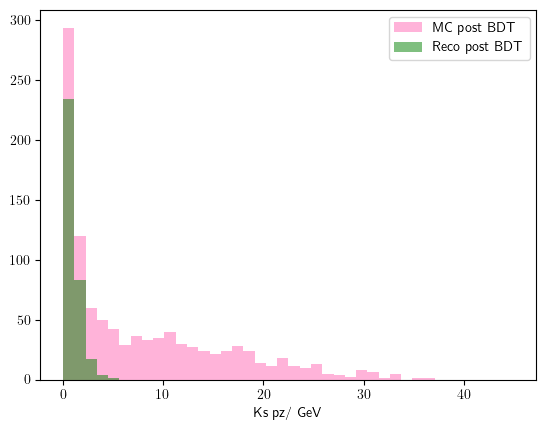

In [127]:

plt.hist(KS_dict_postBDT["KS_pz"], bins =40, density =False, range = (0,45), alpha =0.5, label="MC post BDT", color="hotpink")
plt.hist(KS_pz_arr, bins =40, density =False,  range = (0,45), alpha =0.5, label="Reco post BDT", color="green")
plt.xlabel("Ks pz/ GeV")
plt.legend()
plt.show()

In [132]:
## Also looking at preselection vs BDT SS KS

KS_dict_postBDT_quarterfull = {"KS_idx":[],
           "KS_p":[],
           "KS_px":[],
           "KS_py":[],
           "KS_pz":[],
           "KS_e":[],
           "KS_orivtx_x":[],
           "KS_orivtx_y":[],
           "KS_orivtx_z":[],
           "KS_decvtx_x":[],
           "KS_decvtx_y":[],
           "KS_decvtx_z":[],}

nevents =  Ksnunu_postBDT_tree.GetEntries()
print(nevents)


for i, event in enumerate(Ksnunu_postBDT_tree):
    if i >= nevents/4:
        break
    get_SS_MC_KS_info(event, KS_dict_postBDT_quarterfull)

29226


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [145]:
preseln_path = "/r02/lhcb/ejnw2/FCC_outputs_additional_April26/outputs/ella_INVestigations/p8_ee_Zbb_ecm91_EvtGen_Bd2KsNuNu/chunk_0.root"
preseln_file = ROOT.TFile.Open(preseln_path)
Ksnunu_presel_tree = preseln_file.Get("events")

KS_dict_presel_onechunk = {"KS_idx":[],
           "KS_p":[],
           "KS_px":[],
           "KS_py":[],
           "KS_pz":[],
           "KS_e":[],
           "KS_orivtx_x":[],
           "KS_orivtx_y":[],
           "KS_orivtx_z":[],
           "KS_decvtx_x":[],
           "KS_decvtx_y":[],
           "KS_decvtx_z":[],}


nevents =  Ksnunu_presel_tree.GetEntries()
print(nevents)

KS_decay_vtx_r_presel = []
KS_decay_vtx_z_presel = []
KS_px_arr_presel = []
KS_py_arr_presel = []
KS_pz_arr_presel = []


for i, event in enumerate(Ksnunu_presel_tree):
    get_SS_MC_KS_info(event, KS_dict_presel_onechunk)
    get_SS_reco_KS0_decay_vtx(event, KS_decay_vtx_r_presel, KS_decay_vtx_z_presel, KS_px_arr_presel,KS_py_arr_presel,KS_pz_arr_presel)

80828


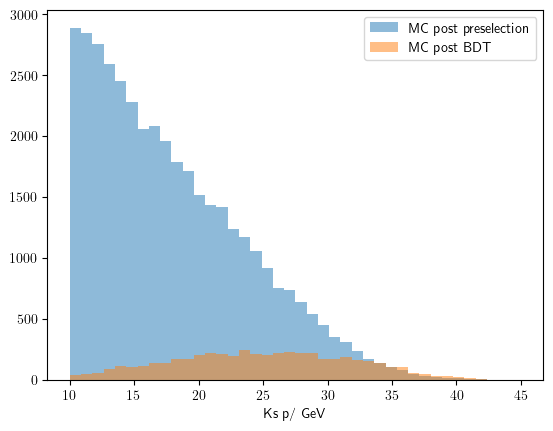

In [143]:
#  presel sample shown here relative factor of 5 smaller than real life cf. post BDT sample
plt.hist(KS_dict_presel_onechunk["KS_p"], bins =40, density =False, range = (10,45), alpha =0.5, label="MC post preselection") 
plt.hist(KS_dict_postBDT_quarterfull["KS_p"], bins =40, density =False,  range = (10,45), alpha =0.5, label="MC post BDT")
plt.xlabel("Ks p/ GeV")
plt.legend()
plt.show()

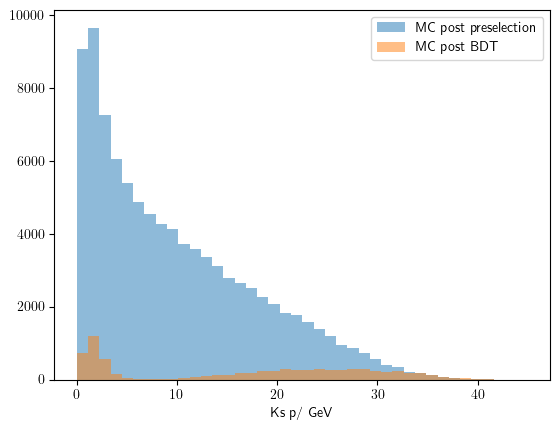

In [144]:

plt.hist(KS_dict_presel_onechunk["KS_p"], bins =40, density =False, range = (0,45), alpha =0.5, label="MC post preselection") 
plt.hist(KS_dict_postBDT_quarterfull["KS_p"], bins =40, density =False,  range = (0,45), alpha =0.5, label="MC post BDT")
plt.xlabel("Ks p/ GeV")
plt.legend()
plt.show()

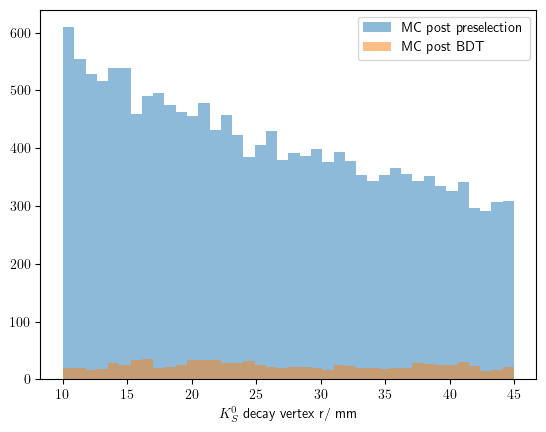

In [139]:
plt.hist(get_KS_decvtx_r(KS_dict_presel_onechunk), bins =40, density =False, range = (10,45), alpha =0.5, label="MC post preselection") # weighted by factor of 5 as currently using arrpox 1/20 of preselection sample and approx 1/4 of BDT sample
plt.hist(get_KS_decvtx_r(KS_dict_postBDT_quarterfull), bins =40, density =False,  range = (10,45), alpha =0.5, label="MC post BDT")
plt.xlabel("$K_S^0$ decay vertex r/ mm")
plt.legend()
plt.show()

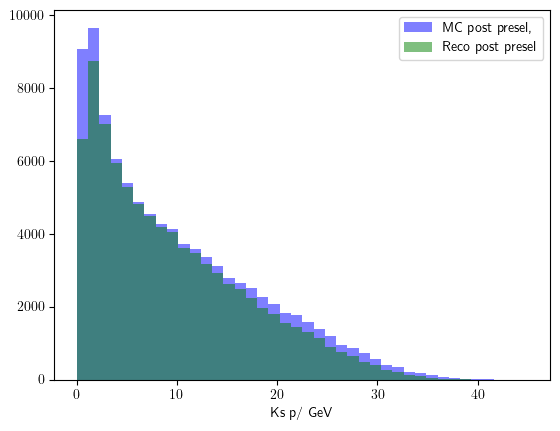

In [146]:
plt.hist(KS_dict_presel_onechunk["KS_p"], bins =40, density =False, range = (0,45), alpha =0.5, label="MC post presel,", color="blue")
plt.hist(np.sqrt(np.array(KS_px_arr_presel)**2+np.array(KS_py_arr_presel)**2+np.array(KS_pz_arr_presel)**2), bins =40, density =False,  range = (0,45), alpha =0.5, label="Reco post presel", color="green")
plt.xlabel("Ks p/ GeV")
plt.legend()
plt.show()

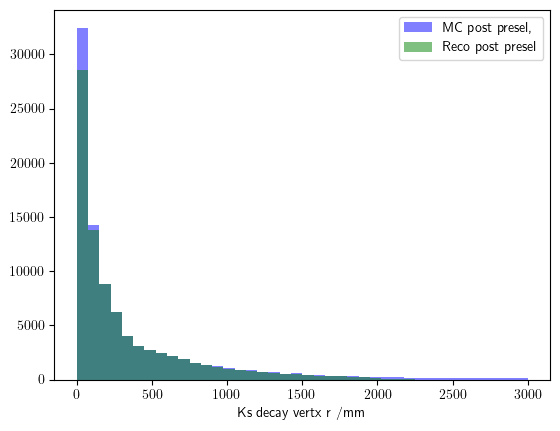

In [149]:
plt.hist(get_KS_decvtx_r(KS_dict_presel_onechunk), bins =40, density =False, range = (0,3000), alpha =0.5, label="MC post presel,", color="blue")
plt.hist(KS_decay_vtx_r_presel, bins =40, density =False,  range = (0,3000), alpha =0.5, label="Reco post presel", color="green")
plt.xlabel("Ks decay vertx r /mm")
plt.legend()
plt.show()